# V2 — DQN Training Analysis — 1H Data

In [1]:
import sys, matplotlib.ticker as mticker
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "../.." ).resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.environment.trading_env import TradingEnv
from src.agents.dqn_agent import build_agent, run_episode
from src.training.trainer import train as train_agent
from stable_baselines3 import DQN

plt.style.use("seaborn-v0_8-darkgrid")
print(f"Project root: {PROJECT_ROOT}")

cfg = yaml.safe_load(open(PROJECT_ROOT / "configs/dqn_config.yaml"))
print(f"total_timesteps : {cfg['training']['total_timesteps']:,}")
print(f"eval_freq       : {cfg['training']['eval_freq']:,}")
print(f"gamma           : {cfg['model']['gamma']}")
print(f"buffer_size     : {cfg['model']['buffer_size']:,}")


Project root: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy
total_timesteps : 500,000
eval_freq       : 25,000
gamma           : 0.9996
buffer_size     : 500,000


## 1. Train the DQN Agent

> **Skip this cell if  already exists.**
> Re-run only to retrain from scratch.

In [2]:
best_model_path = PROJECT_ROOT / "models/best/best_model.zip"
print(f"Checking for existing model: {best_model_path}")

if best_model_path.exists():
    print("best_model.zip already exists — skipping training.")
    print("Delete models/best/best_model.zip to retrain from scratch.")
else:
    print("No model found — starting training...")
    df_train = pd.read_csv(PROJECT_ROOT / "data/normalized/train.csv", index_col=0, parse_dates=True)
    df_val   = pd.read_csv(PROJECT_ROOT / "data/normalized/val.csv",   index_col=0, parse_dates=True)
    print(f"Train: {len(df_train):,} rows  |  Val: {len(df_val):,} rows")

    env_train = TradingEnv(df_train, cfg["environment"])
    env_val   = TradingEnv(df_val,   cfg["environment"])
    print(f"Env built — episode steps: {env_train.n_steps:,}")

    model_cfg = cfg["model"].copy()
    model_cfg["seed"] = cfg["training"]["seed"]
    agent = build_agent(env_train, model_cfg)
    print("Agent built — starting learn()...")

    agent = train_agent(env_train, env_val, agent, cfg["training"])
    agent.save(str(PROJECT_ROOT / "models/dqn_v2_final"))
    print(f"Training complete. Model saved → {PROJECT_ROOT}/models/dqn_v2_final.zip")


Checking for existing model: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy/models/best/best_model.zip
best_model.zip already exists — skipping training.
Delete models/best/best_model.zip to retrain from scratch.


## 2. Load Learning Curve

In [3]:
log_path = PROJECT_ROOT / "results/logs/evaluations.npz"
print(f"Loading learning curve from: {log_path}")
print(f"Exists: {log_path.exists()}")

data      = np.load(log_path)
timesteps = data["timesteps"]
rewards   = data["results"].mean(axis=1)

print(f"Evaluations logged : {len(timesteps)}")
print(f"Steps range        : {timesteps[0]:,} → {timesteps[-1]:,}")
print(f"Best val reward    : {rewards.max():.4f} at step {timesteps[rewards.argmax()]:,}")
print(f"Final val reward   : {rewards[-1]:.4f}")


Loading learning curve from: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy/results/logs/evaluations.npz
Exists: True
Evaluations logged : 18
Steps range        : 25,000 → 450,000
Best val reward    : 0.0786 at step 300,000
Final val reward   : 0.0686


## 3. Learning Curve Plot

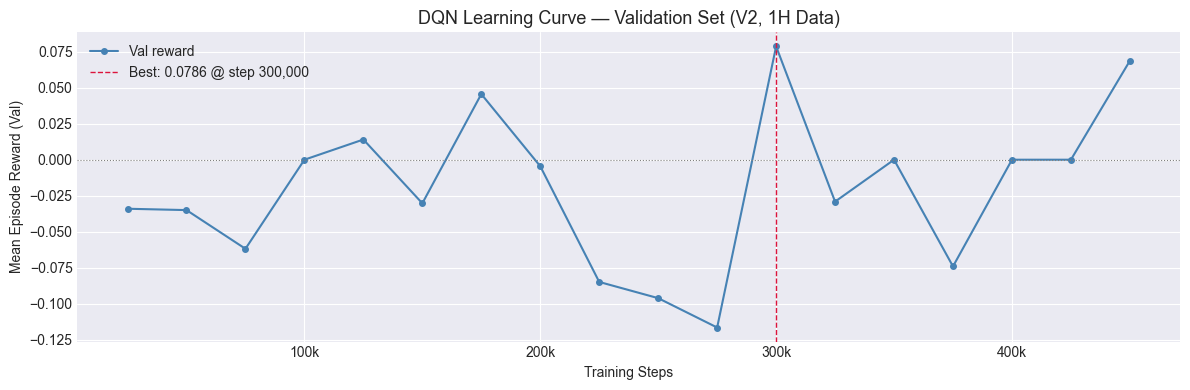

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(timesteps, rewards, marker="o", markersize=4, linewidth=1.5, color="steelblue", label="Val reward")
ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
best_step = timesteps[rewards.argmax()]
best_r    = rewards.max()
ax.axvline(best_step, color="crimson", linewidth=1, linestyle="--", label=f"Best: {best_r:.4f} @ step {best_step:,}")
ax.set_xlabel("Training Steps")
ax.set_ylabel("Mean Episode Reward (Val)")
ax.set_title("DQN Learning Curve — Validation Set (V2, 1H Data)", fontsize=13)
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_04_learning_curve.png", dpi=150)
plt.show()


## 4. Val Set — Best Model Portfolio

Val rows: 720  (2024-09-01 → 2024-09-30)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Model loaded: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy/models/best/best_model.zip
Running episode on val set...
Episode done — 720 steps recorded
Actions — Hold: 39  Buy: 362  Sell: 319


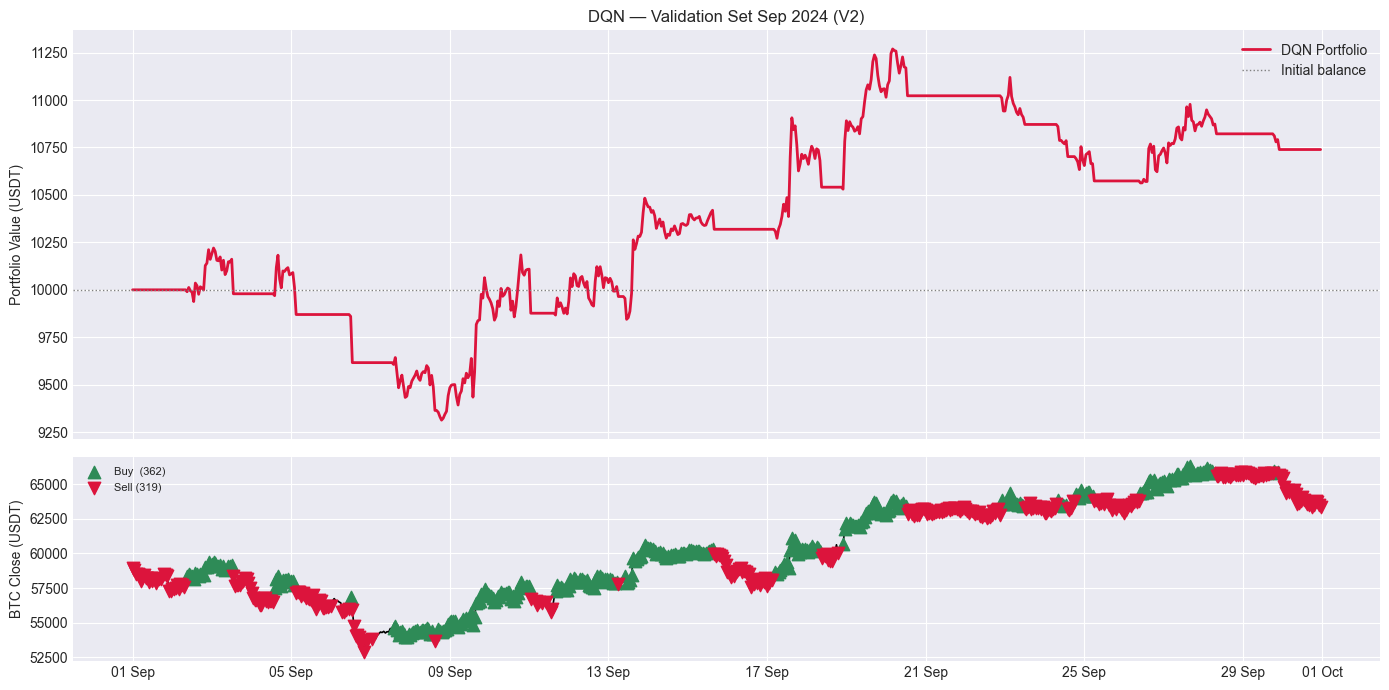

DQN val return: +7.39%


In [5]:
df_val_norm = pd.read_csv(PROJECT_ROOT / "data/normalized/val.csv", index_col=0, parse_dates=True)
df_val_feat = pd.read_csv(PROJECT_ROOT / "data/features/val.csv",  index_col=0, parse_dates=True)
print(f"Val rows: {len(df_val_norm):,}  ({df_val_feat.index[0].date()} → {df_val_feat.index[-1].date()})")

env_val = TradingEnv(df_val_norm, cfg["environment"])
agent   = DQN.load(str(PROJECT_ROOT / "models/best/best_model"), env=env_val)
print(f"Model loaded: {PROJECT_ROOT}/models/best/best_model.zip")
print(f"Running episode on val set...")

trace = run_episode(agent, env_val)
print(f"Episode done — {len(trace)} steps recorded")
print(f"Actions — Hold: {(trace['action']==0).sum()}  Buy: {(trace['action']==1).sum()}  Sell: {(trace['action']==2).sum()}")

ib    = cfg["environment"]["initial_balance"]
dates = df_val_feat.index

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

scaled = trace["portfolio_value"] / trace["portfolio_value"].iloc[0] * ib
ax1.plot(dates, scaled, color="crimson", linewidth=2, label="DQN Portfolio")
ax1.axhline(ib, color="grey", linewidth=1, linestyle=":", label="Initial balance")
ax1.set_ylabel("Portfolio Value (USDT)")
ax1.set_title("DQN — Validation Set Sep 2024 (V2)")
ax1.legend()

buy_idx  = trace["action"].values == 1
sell_idx = trace["action"].values == 2
ax2.plot(dates, df_val_feat["close"], color="black", linewidth=1.2)
ax2.scatter(dates[buy_idx],  df_val_feat["close"].values[buy_idx],  marker="^", color="seagreen", s=80, zorder=5, label=f"Buy  ({buy_idx.sum()})")
ax2.scatter(dates[sell_idx], df_val_feat["close"].values[sell_idx], marker="v", color="crimson",  s=80, zorder=5, label=f"Sell ({sell_idx.sum()})")
ax2.set_ylabel("BTC Close (USDT)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_04_dqn_val_analysis.png", dpi=150)
plt.show()

val_ret = (trace["portfolio_value"].iloc[-1] / trace["portfolio_value"].iloc[0] - 1) * 100
print(f"DQN val return: {val_ret:+.2f}%")
